In [349]:
import pandas as pd
import matplotlib.pyplot as plt


In [350]:
df = pd.read_csv('Пример выгрузки - Лист 1.csv')
df.isna().sum()

day           0
product       0
cost          0
revenue       0
profit        0
clicks        0
conversion    0
sales         0
dtype: int64

In [351]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   day         60 non-null     object
 1   product     60 non-null     object
 2   cost        60 non-null     object
 3   revenue     60 non-null     object
 4   profit      60 non-null     object
 5   clicks      60 non-null     int64 
 6   conversion  60 non-null     int64 
 7   sales       60 non-null     int64 
dtypes: int64(3), object(5)
memory usage: 3.9+ KB


In [376]:
df.groupby('product').size()


product
Product A    30
Product B    30
dtype: int64

In [353]:
df['cost'] = df['cost'].str.replace(',', '.').astype(float)
df['revenue'] = df['revenue'].str.replace(',', '.').astype(float)

In [354]:
df['day'] = pd.to_datetime(df['day'], format='%d.%m.%Y')

In [355]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   day         60 non-null     datetime64[ns]
 1   product     60 non-null     object        
 2   cost        60 non-null     float64       
 3   revenue     60 non-null     float64       
 4   profit      60 non-null     object        
 5   clicks      60 non-null     int64         
 6   conversion  60 non-null     int64         
 7   sales       60 non-null     int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(2)
memory usage: 3.9+ KB


In [356]:
# № 1 Каковы ROI продуктов A и B за рассматриваемый период?
#ROI  (рентабельность инвестиций)  змеряет, сколько прибыли принесли вам вложенные средства
# (revenue(выручка) - cost(себестоимасть)) / cost(себестоимасть) * 100

In [357]:
df_group_sum = df.groupby('product').aggregate({'cost':'sum', 'revenue':'sum'}).reset_index()
df.head()


,day,product,cost,revenue,profit,clicks,conversion,sales
0,2023-10-01,Product A,160.9615,195.0,"34,04",1870,68,15
1,2023-10-01,Product B,679.8214,1020.0,"340,18",5049,119,34
2,2023-10-02,Product A,125.6251,182.0,"56,37",1590,55,14
3,2023-10-02,Product B,688.8210,1050.0,"361,18",6033,130,35
4,2023-10-03,Product A,136.8409,208.0,"71,16",1790,77,16


In [358]:
round(((df_group_sum['revenue'] - df_group_sum['cost']) / df_group_sum['cost']) * 100, 2)

0    30.14
1    46.97
dtype: float64

In [359]:
# ROI для Product A и Product B за рассматриваемый период соответственно  30.14% и 46.97%.

 № 2 У какого продукта выше средний дневной профит и сколько он составляет?
Также укажите медианный дневной профит по каждому продукту: у какого он выше и чему равен?

In [360]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   day         60 non-null     datetime64[ns]
 1   product     60 non-null     object        
 2   cost        60 non-null     float64       
 3   revenue     60 non-null     float64       
 4   profit      60 non-null     object        
 5   clicks      60 non-null     int64         
 6   conversion  60 non-null     int64         
 7   sales       60 non-null     int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(2)
memory usage: 3.9+ KB


In [361]:
df['profit'] = df['profit'].str.replace(',','.').astype(float)

In [362]:
avg_profit = df.groupby('product').aggregate({'profit':'mean'}).reset_index()
avg_profit

,product,profit
0,Product A,116.180333
1,Product B,327.077333


In [363]:
# У Product B выше средний дневной профит и он составляет 327,08

Также укажите медианный дневной профит по каждому продукту: у какого он выше и чему равен?

In [364]:
median_profit = df.groupby('product').aggregate({'profit':'median'}).reset_index()
median_profit

,product,profit
0,Product A,93.085
1,Product B,334.455


In [365]:
#Так же медианный дневной профит выше Product B - 334.455
 

В Google Sheets рассчитайте CR по дням:
для продукта A
для продукта B
общий CR по обоим продуктам
Постройте график, добавьте подписи осей и легенду.


In [366]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   day         60 non-null     datetime64[ns]
 1   product     60 non-null     object        
 2   cost        60 non-null     float64       
 3   revenue     60 non-null     float64       
 4   profit      60 non-null     float64       
 5   clicks      60 non-null     int64         
 6   conversion  60 non-null     int64         
 7   sales       60 non-null     int64         
dtypes: datetime64[ns](1), float64(3), int64(3), object(1)
memory usage: 3.9+ KB


In [367]:
# CR (Conversion Rate) - конверсия 
# (целевые действия(продажи sales) / (clicks) × 100%

In [368]:
#CR по дням:
#для продукта A
# для продукта B
df['CR'] = df['sales'] / df['clicks']
df.head()

,day,product,cost,revenue,profit,clicks,conversion,sales,CR
0,2023-10-01,Product A,160.9615,195.0,34.04,1870,68,15,0.008021
1,2023-10-01,Product B,679.8214,1020.0,340.18,5049,119,34,0.006734
2,2023-10-02,Product A,125.6251,182.0,56.37,1590,55,14,0.008805
3,2023-10-02,Product B,688.8210,1050.0,361.18,6033,130,35,0.005801
4,2023-10-03,Product A,136.8409,208.0,71.16,1790,77,16,0.008939


In [369]:
# CR по дням для продукта A
CR_product_a = df.query('product == "Product A"').groupby('day').aggregate({'CR':'mean'}).reset_index()
CR_product_a



,day,CR
0,2023-10-01,0.008021
1,2023-10-02,0.008805
2,2023-10-03,0.008939
3,2023-10-04,0.004165
4,2023-10-05,0.005207
5,2023-10-06,0.004077
6,2023-10-07,0.007849
7,2023-10-08,0.006017
8,2023-10-09,0.007374
9,2023-10-10,0.007666


In [370]:
# CR по дням для продукта B

In [371]:
CR_product_B = df.query('product == "Product B"').groupby('day').aggregate({'CR':'mean'}).reset_index()
CR_product_B


,day,CR
0,2023-10-01,0.006734
1,2023-10-02,0.005801
2,2023-10-03,0.005037
3,2023-10-04,0.006045
4,2023-10-05,0.007746
5,2023-10-06,0.006092
6,2023-10-07,0.006509
7,2023-10-08,0.005020
8,2023-10-09,0.005934
9,2023-10-10,0.007606


In [372]:
# общий CR по обоим продуктам

In [373]:

CR_total = df.groupby('day').aggregate({'sales':'sum','clicks':'sum'}).reset_index()
CR_total['CR'] = CR_total['sales'] / CR_total['clicks']
CR_total

,day,sales,clicks,CR
0,2023-10-01,49,6919,0.007082
1,2023-10-02,49,7623,0.006428
2,2023-10-03,42,6952,0.006041
3,2023-10-04,49,9002,0.005443
4,2023-10-05,60,8942,0.006710
5,2023-10-06,50,9424,0.005306
6,2023-10-07,58,8203,0.007071
7,2023-10-08,45,8304,0.005419
8,2023-10-09,52,8006,0.006495
9,2023-10-10,65,8518,0.007631


Постройте график, добавьте подписи осей и легенду.

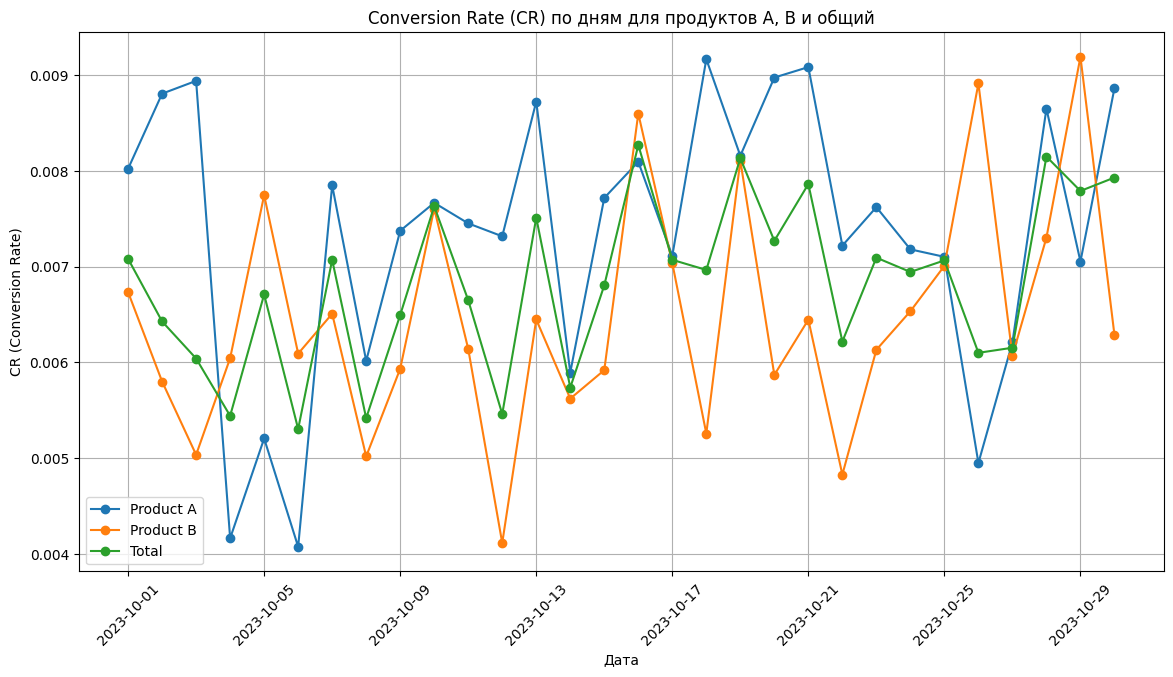

In [374]:
plt.figure(figsize=(14, 7))

# График для продукта A
plt.plot(CR_product_a['day'], CR_product_a['CR'], marker='o', label='Product A')
# График для продукта B
plt.plot(CR_product_B['day'], CR_product_B['CR'], marker='o', label='Product B')
# График общего CR
plt.plot(CR_total['day'], CR_total['CR'], marker='o', label='Total')
# Подписи осей
plt.xlabel('Дата')
plt.ylabel('CR (Conversion Rate)')
# Заголовок
plt.title('Conversion Rate (CR) по дням для продуктов A, B и общий')
# Поворот меток по оси X для удобства чтения
plt.xticks(rotation=45)
# Легенда
plt.legend()
# Отобразить сетку
plt.grid(True)



In [375]:
#  Какие дополнительные метрики вы бы рассчитали на основе имеющихся данных и зачем?